In [1]:
from utils.constants import *
from utils.histogram_computation import *
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
import pandas as pd
import shutil
import os

#import kagglehub
"""
RUN THIS CELL, NECESSARY IMPORTS
#pip install kagglehub[pandas-datasets] to download dataset
 

os.makedirs('gtrsb_dataset', exist_ok=True)
dataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(f"Dataset downloaded to: {dataset_path}")

# move the dataset to current project directory
target_path = './gtrsb_dataset'
if os.path.exists(target_path):
    shutil.move(dataset_path, target_path)


pd.read_csv(os.path.join(DF_PATH, 'Test.csv'))
"""

'\nRUN THIS CELL, NECESSARY IMPORTS\n#pip install kagglehub[pandas-datasets] to download dataset\n \n\nos.makedirs(\'gtrsb_dataset\', exist_ok=True)\ndataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")\nprint(f"Dataset downloaded to: {dataset_path}")\n\n# move the dataset to current project directory\ntarget_path = \'./gtrsb_dataset\'\nif os.path.exists(target_path):\n    shutil.move(dataset_path, target_path)\n\n\npd.read_csv(os.path.join(DF_PATH, \'Test.csv\'))\n'

# RUN CELL ABOVE FIRST

In [4]:
def run_experiment(SEED: int = 4):
    train_df = pd.read_csv(os.path.join(DF_PATH, 'Train.csv'))
    test_df = pd.read_csv(os.path.join(DF_PATH, 'Test.csv'))
    meta_df = pd.read_csv(os.path.join(DF_PATH, 'Meta.csv'))
    for df in [train_df, test_df]:
        df["roi_w"] = (df["Roi.X2"] - df["Roi.X1"]).clip(lower=1)
        df["roi_h"] = (df["Roi.Y2"] - df["Roi.Y1"]).clip(lower=1)
        df["img_area"] = df["Width"] * df["Height"]
        df["roi_area"] = df["roi_w"] * df["roi_h"]
        df["roi_cover"] = (df["roi_area"] / df["img_area"]).clip(upper=1.0)

    test_df = test_df.merge(
        meta_df[['ClassId', 'ColorId', 'ShapeId', 'SignId']],
        how='left',      
        on='ClassId'     
    )
    train_df = train_df.merge(
        meta_df[['ClassId', 'ColorId', 'ShapeId', 'SignId']],
        how='left',      
        on='ClassId'     
    )

    #columns = [['ColorId', 'ShapeId']]
    #train = train_df[['ColorId', 'ShapeId']]
    #test = test_df[['ColorId', 'ShapeId']]
    #test['SignId'] = test['SignId'].astype('category').cat.codes
    #train['SignId'] = train['SignId'].astype('category').cat.codes


    #df = pd.concat([train_df, test_df])


    # clear separate test and train
    features_df_train, failed = extract_histograms_from_dataset(train_df)
    features_df_test, failed = extract_histograms_from_dataset(test_df)

    print(f"Columns: {features_df_train.columns.tolist()}")

    # should cross validate
    X_train, X_test, y_train, y_test = create_feature_sets_with_hog(features_df_train, features_df_test, train_df, test_df)
    
    print(f"Feature shape: {X_train.shape}")

    # Normalize for gradient based algos
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_test_std = scaler.transform(X_test)

    # try different parameters
    model = SVC(kernel='rbf', C=1.0, random_state=SEED)
    model.fit(X_train_std, y_train)
    y_pred = model.predict(X_test_std)

    #model = RandomForestClassifier()
    #model.fit(X_train, y_train)
    #y_pred = model.predict(X_test)
    # should try with different params
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    return model, train_df, y_test, y_pred

model, df, y_test, y_pred = run_experiment(SEED = 4)


Processed 0 samples...
Processed 1000 samples...
Processed 2000 samples...
Processed 3000 samples...
Processed 4000 samples...
Processed 5000 samples...
Processed 6000 samples...
Processed 7000 samples...
Processed 8000 samples...
Processed 9000 samples...
Processed 10000 samples...
Processed 11000 samples...
Processed 12000 samples...
Processed 13000 samples...
Processed 14000 samples...
Processed 15000 samples...
Processed 16000 samples...
Processed 17000 samples...
Processed 18000 samples...
Processed 19000 samples...
Processed 20000 samples...
Processed 21000 samples...
Processed 22000 samples...
Processed 23000 samples...
Processed 24000 samples...
Processed 25000 samples...
Processed 26000 samples...
Processed 27000 samples...
Processed 28000 samples...
Processed 29000 samples...
Processed 30000 samples...
Processed 31000 samples...
Processed 32000 samples...
Processed 33000 samples...
Processed 34000 samples...
Processed 35000 samples...
Processed 36000 samples...
Processed 3700

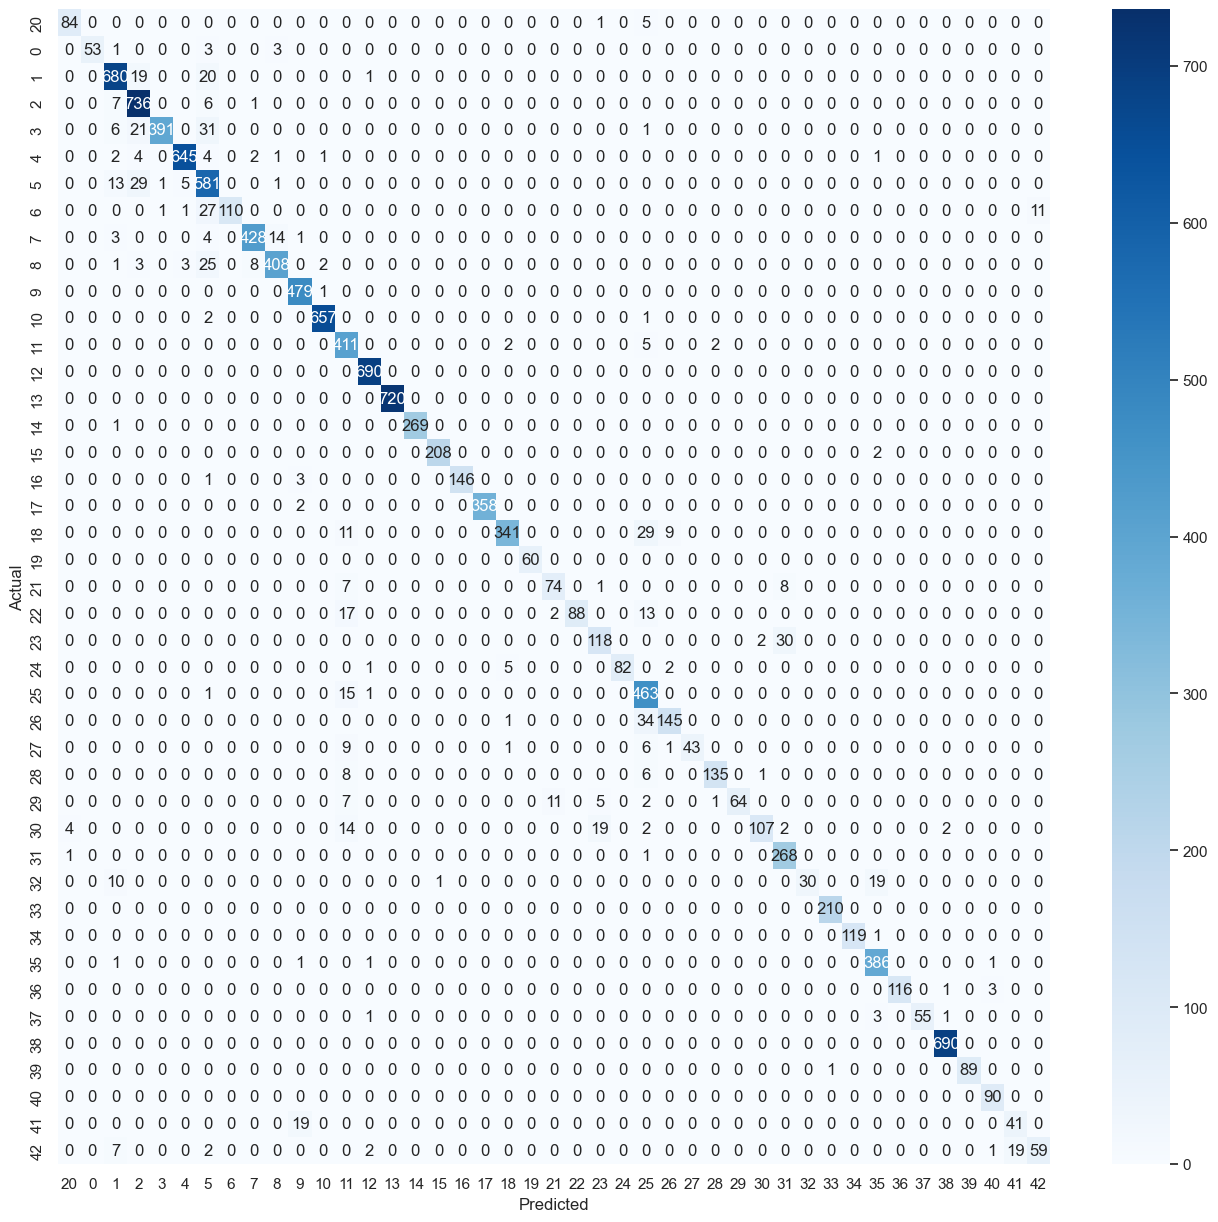

In [5]:


import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred, labels=df['ClassId'].unique())
sns.set(rc={"figure.figsize":(16, 15)}) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels= df['ClassId'].unique(), yticklabels=df['ClassId'].unique())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()